# Notebook 00 — Data Preparation (Shared)

Notebook **dùng chung cho cả 3 người**. Mục tiêu:

1. Tải dataset **UIT-VSFC** (Vietnamese Students' Feedback Corpus).
2. Phân tích sơ bộ (statistics, class distribution, length distribution).
3. Tiền xử lý tiếng Việt: lowercase → remove URL/digit/punctuation → tokenize bằng `underthesea` → remove stopwords.
4. Xuất ra `data/processed/{train,dev,test}.csv` để 3 người tái sử dụng.

**Output cuối:** 3 file CSV có cột `text`, `text_clean`, `label`.

In [1]:
import os, re, sys, string, zipfile, io, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw' / 'UIT-VSFC'
PROC = ROOT / 'data' / 'processed'
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)
print('RAW :', RAW)
print('PROC:', PROC)

RAW : D:\VCODE\NLPF\data\raw\UIT-VSFC
PROC: D:\VCODE\NLPF\data\processed


## 1. Tải dataset

Pipeline tải data đi theo thứ tự ưu tiên (cái nào có sẵn dùng cái đó):

1. **File raw có sẵn** trong `data/raw/UIT-VSFC/{train,dev,test}/{sents.txt,sentiments.txt}` → load trực tiếp.
2. **HuggingFace Hub** — mirror `uitnlp/vietnamese_students_feedback` (cần `datasets`, mạng).
3. **Fallback sample** (~300 dòng có sẵn trong notebook) — dùng để smoke-test pipeline khi không có mạng.

Tại sao chọn HuggingFace? Vì link Google Drive gốc của UIT thường đổi/hết hạn, còn HF mirror ổn định, tải 1 dòng `load_dataset(...)` là xong.

In [2]:
# Kiểm tra file raw đã có sẵn dạng UIT-VSFC chuẩn chưa (sents.txt + sentiments.txt)
def has_raw_files() -> bool:
    for s in ['train', 'dev', 'test']:
        if not (RAW / s / 'sents.txt').exists():
            return False
        if not (RAW / s / 'sentiments.txt').exists():
            return False
    return True

# Trạng thái sẽ được set sau khi load thành công (raw / hf / sample)
DATA_MODE = None
hf_dataset = None

if has_raw_files():
    DATA_MODE = 'raw'
    print('[OK] UIT-VSFC raw files đã có sẵn trong', RAW)
else:
    # Thử HuggingFace mirror — ổn định hơn link Google Drive gốc
    print('[INFO] Chưa có raw files. Thử tải từ HuggingFace Hub...')
    try:
        from datasets import load_dataset
        hf_dataset = load_dataset('uitnlp/vietnamese_students_feedback')
        DATA_MODE = 'hf'
        print('[OK] Đã tải xong từ HuggingFace:',
              {k: len(v) for k, v in hf_dataset.items()})
    except Exception as e:
        print('[WARN] Tải HuggingFace fail:', e)
        print('[WARN] Sẽ dùng SAMPLE (~300 dòng) để test pipeline.')
        print('       Để có kết quả đầy đủ, xem data/README.md hướng dẫn tải tay.')
        DATA_MODE = 'sample'

[INFO] Chưa có raw files. Thử tải từ HuggingFace Hub...


README.md:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

D:\VCODE\NLPF\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\datasets--uitnlp--vietnamese_students_feedback. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vietnamese_students_feedback.py:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

[WARN] Tải HuggingFace fail: Dataset scripts are no longer supported, but found vietnamese_students_feedback.py
[WARN] Sẽ dùng SAMPLE (~300 dòng) để test pipeline.
       Để có kết quả đầy đủ, xem data/README.md hướng dẫn tải tay.


In [3]:
# === Fallback sample dataset (chỉ chạy nếu không có UIT-VSFC thật) ===
# Cân bằng 3 lớp 0/1/2 cho mục đích smoke-test pipeline.
SAMPLE_NEG = [
    'Giảng viên dạy quá nhanh, sinh viên không kịp hiểu.',
    'Bài giảng buồn ngủ, nội dung lặp lại nhiều.',
    'Phòng học nóng, máy chiếu hỏng liên tục.',
    'Đề thi quá khó so với những gì đã học.',
    'Thầy ít quan tâm câu hỏi của sinh viên.',
    'Tài liệu môn học cũ, không cập nhật.',
    'Lịch học bị thay đổi liên tục gây bất tiện.',
    'Bài tập nhóm phân chia không công bằng.',
    'Cách chấm điểm thiếu minh bạch.',
    'Wifi trong lớp kém, học online rất khó chịu.',
]
SAMPLE_NEU = [
    'Môn học có nội dung như mô tả trong syllabus.',
    'Giảng viên giảng dạy theo slide có sẵn.',
    'Lớp học diễn ra đúng giờ quy định.',
    'Đề thi gồm phần lý thuyết và bài tập.',
    'Bài giảng được thu âm và đăng tải sau buổi học.',
    'Sinh viên có thể chọn đề tài tiểu luận.',
    'Lịch nộp bài tập được công bố trên hệ thống.',
    'Phòng học có máy chiếu và bảng trắng.',
    'Tài liệu được chia sẻ qua email lớp.',
    'Buổi thảo luận tổ chức vào cuối kỳ.',
]
SAMPLE_POS = [
    'Giảng viên giảng rất dễ hiểu và nhiệt tình.',
    'Môn học cực kỳ bổ ích, em học được nhiều kiến thức.',
    'Thầy luôn sẵn sàng giải đáp thắc mắc của sinh viên.',
    'Slide bài giảng đẹp, trực quan, dễ tiếp thu.',
    'Cách dạy hài hước, không gây buồn ngủ.',
    'Bài tập thực tế, áp dụng được cho dự án cá nhân.',
    'Đánh giá công bằng, có feedback chi tiết cho từng sinh viên.',
    'Em rất thích phong cách giảng dạy của cô.',
    'Môn học truyền cảm hứng nghiên cứu cho sinh viên.',
    'Tài liệu phong phú, cập nhật mới nhất.',
]

def build_sample(n_per_class_train=70, n_per_class_dev=10, n_per_class_test=20, seed=42):
    rng = random.Random(seed)
    def make(sents, label, n):
        out = []
        for _ in range(n):
            base = rng.choice(sents)
            # nhiễu nhẹ để tránh trùng lặp 100%
            if rng.random() < 0.3: base = base + ' Ổn.'
            if rng.random() < 0.2: base = 'Theo em, ' + base
            out.append((base, label))
        return out
    train, dev, test = [], [], []
    for lbl, sents in [(0, SAMPLE_NEG), (1, SAMPLE_NEU), (2, SAMPLE_POS)]:
        train += make(sents, lbl, n_per_class_train)
        dev   += make(sents, lbl, n_per_class_dev)
        test  += make(sents, lbl, n_per_class_test)
    rng.shuffle(train); rng.shuffle(dev); rng.shuffle(test)
    df_train = pd.DataFrame(train, columns=['text','label'])
    df_dev   = pd.DataFrame(dev,   columns=['text','label'])
    df_test  = pd.DataFrame(test,  columns=['text','label'])
    return df_train, df_dev, df_test

In [4]:
# Helper load từ raw files theo format UIT-VSFC gốc
def load_uitvsfc_split(split: str) -> pd.DataFrame:
    base = RAW / split
    sents = (base / 'sents.txt').read_text(encoding='utf-8').splitlines()
    labels = (base / 'sentiments.txt').read_text(encoding='utf-8').splitlines()
    assert len(sents) == len(labels), f'Length mismatch in {split}'
    return pd.DataFrame({'text': sents, 'label': [int(x) for x in labels]})

# Helper convert HuggingFace dataset -> DataFrame có cùng schema (text, label)
# HF mirror UIT-VSFC dùng cột 'sentence' và 'sentiment' nên cần map lại.
def hf_split_to_df(hf_split) -> pd.DataFrame:
    # Tự dò tên cột text/label vì các mirror có thể khác nhau
    cols = hf_split.column_names
    text_col = next((c for c in ['sentence', 'text', 'sent'] if c in cols), cols[0])
    label_col = next((c for c in ['sentiment', 'label', 'labels'] if c in cols), cols[-1])
    return pd.DataFrame({
        'text': hf_split[text_col],
        'label': [int(x) for x in hf_split[label_col]],
    })

if DATA_MODE == 'raw':
    df_train = load_uitvsfc_split('train')
    df_dev = load_uitvsfc_split('dev')
    df_test = load_uitvsfc_split('test')
    DATA_SOURCE = 'UIT-VSFC (raw files)'
elif DATA_MODE == 'hf':
    df_train = hf_split_to_df(hf_dataset['train'])
    df_dev = hf_split_to_df(hf_dataset['validation']) if 'validation' in hf_dataset else hf_split_to_df(hf_dataset.get('dev'))
    df_test = hf_split_to_df(hf_dataset['test'])
    DATA_SOURCE = 'UIT-VSFC (HuggingFace mirror)'
else:
    df_train, df_dev, df_test = build_sample()
    DATA_SOURCE = 'SAMPLE (~300 rows, demo only)'

print(f'Source: {DATA_SOURCE}')
print(f'Train: {df_train.shape}  Dev: {df_dev.shape}  Test: {df_test.shape}')
df_train.head()

Source: SAMPLE (~300 rows, demo only)
Train: (210, 2)  Dev: (30, 2)  Test: (60, 2)


,text,label
0,Lịch nộp bài tập được công bố trên hệ thống.,1
1,"Wifi trong lớp kém, học online rất khó chịu.",0
2,"Theo em, Em rất thích phong cách giảng dạy của...",2
3,Giảng viên giảng rất dễ hiểu và nhiệt tình.,2
4,Đề thi gồm phần lý thuyết và bài tập.,1


## 2. Phân tích sơ bộ

Lấy số liệu để viết báo cáo (class distribution, độ dài câu, top từ vựng).

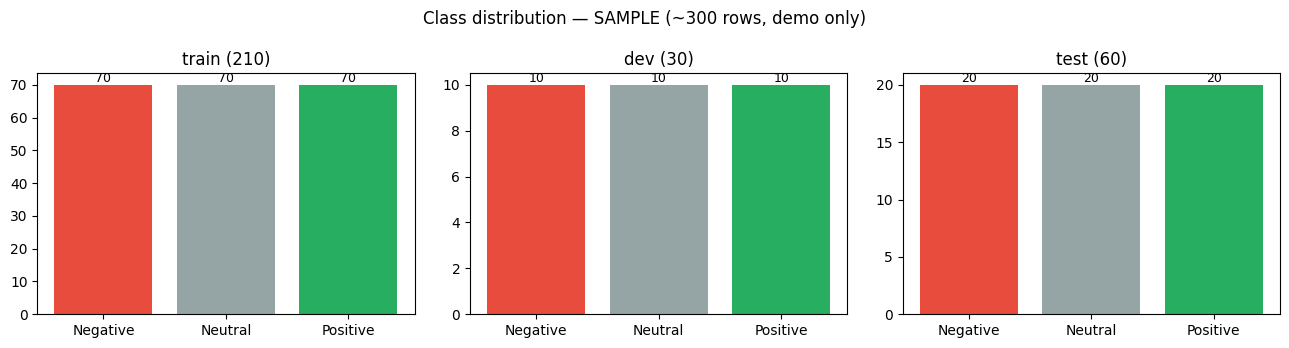

In [5]:
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, df) in zip(axes, [('train', df_train), ('dev', df_dev), ('test', df_test)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values, color=['#e74c3c','#95a5a6','#27ae60'])
    ax.set_title(f'{name} ({len(df)})')
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.suptitle(f'Class distribution — {DATA_SOURCE}')
plt.tight_layout(); plt.show()

Độ dài câu (số từ thô):
  min=6  max=14  mean=9.7  median=10  p95=12


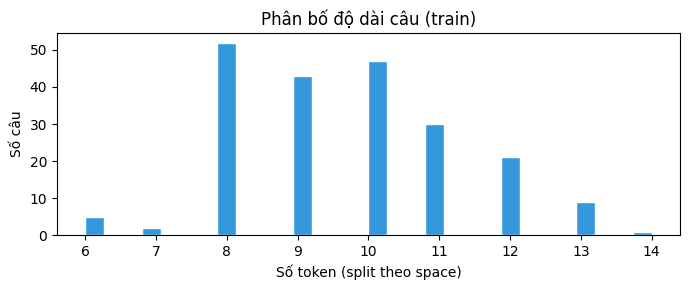

In [6]:
lengths = df_train['text'].str.split().str.len()
print('Độ dài câu (số từ thô):')
print(f'  min={lengths.min()}  max={lengths.max()}  mean={lengths.mean():.1f}  median={lengths.median():.0f}  p95={lengths.quantile(0.95):.0f}')

plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=30, color='#3498db', edgecolor='white')
plt.title('Phân bố độ dài câu (train)')
plt.xlabel('Số token (split theo space)'); plt.ylabel('Số câu')
plt.tight_layout(); plt.show()

## 3. Tiền xử lý văn bản tiếng Việt

Pipeline:
1. **Lowercase**
2. **Remove URLs / digits / punctuation / emoji**
3. **Word segmentation** (`underthesea`) — quan trọng vì tiếng Việt có từ ghép.
4. **Remove stopwords** (danh sách rút gọn)
5. **Strip whitespace**

In [7]:
from underthesea import word_tokenize

VN_STOPWORDS = set([
    'và','là','của','có','được','trong','cho','khi','thì','đã','đang','sẽ','cũng',
    'này','đó','kia','để','như','với','mà','một','các','những','rất','quá','lắm',
    'ạ','nhé','nha','ơi','thế','vậy','rồi','nữa','lại','chỉ','vẫn','còn','hơn','bị',
    'từ','về','trên','dưới','ngoài','bên','theo','vào','ra','lên','xuống'
])

PUNCT = string.punctuation + '“”‘’–—…•·«»\u200b'
URL_RE = re.compile(r'http\S+|www\.\S+')
DIGIT_RE = re.compile(r'\d+')
SPACE_RE = re.compile(r'\s+')
EMOJI_RE = re.compile(
    '[\U0001F300-\U0001F9FF\U0001FA00-\U0001FAFF\u2600-\u27BF]+'
)

def basic_clean(text: str) -> str:
    t = str(text).lower()
    t = URL_RE.sub(' ', t)
    t = EMOJI_RE.sub(' ', t)
    t = DIGIT_RE.sub(' ', t)
    t = t.translate(str.maketrans('', '', PUNCT))
    t = SPACE_RE.sub(' ', t).strip()
    return t

def vn_tokenize(text: str) -> str:
    # underthesea trả về tokens cách nhau bằng dấu cách, từ ghép nối bằng '_'
    return word_tokenize(text, format='text')

def remove_stopwords(text: str) -> str:
    return ' '.join(w for w in text.split() if w not in VN_STOPWORDS)

def preprocess(text: str) -> str:
    t = basic_clean(text)
    t = vn_tokenize(t)
    t = remove_stopwords(t)
    return t

# Demo
for s in [
    'Sản phẩm RẤT tốt, giao hàng nhanh!!! 🚀',
    'Giảng viên dạy quá nhanh, không kịp hiểu :(',
    'Lớp học diễn ra lúc 7h30 sáng.'
]:
    print('IN :', s)
    print('OUT:', preprocess(s))
    print('-' * 60)

IN : Sản phẩm RẤT tốt, giao hàng nhanh!!! 🚀
OUT: sản_phẩm tốt giao hàng nhanh
------------------------------------------------------------
IN : Giảng viên dạy quá nhanh, không kịp hiểu :(
OUT: giảng_viên dạy nhanh không kịp hiểu
------------------------------------------------------------
IN : Lớp học diễn ra lúc 7h30 sáng.
OUT: lớp_học diễn lúc h sáng
------------------------------------------------------------


In [8]:
from tqdm.auto import tqdm
tqdm.pandas(desc='preprocessing')

df_train['text_clean'] = df_train['text'].progress_map(preprocess)
df_dev['text_clean']   = df_dev['text'].progress_map(preprocess)
df_test['text_clean']  = df_test['text'].progress_map(preprocess)

df_train.head()

preprocessing:   0%|          | 0/210 [00:00<?, ?it/s]

preprocessing:   0%|          | 0/30 [00:00<?, ?it/s]

preprocessing:   0%|          | 0/60 [00:00<?, ?it/s]

,text,label,text_clean
0,Lịch nộp bài tập được công bố trên hệ thống.,1,lịch nộp bài_tập công_bố hệ_thống
1,"Wifi trong lớp kém, học online rất khó chịu.",0,wifi lớp kém học online khó_chịu
2,"Theo em, Em rất thích phong cách giảng dạy của...",2,em em thích phong_cách giảng_dạy cô ổn
3,Giảng viên giảng rất dễ hiểu và nhiệt tình.,2,giảng_viên giảng dễ hiểu nhiệt_tình
4,Đề thi gồm phần lý thuyết và bài tập.,1,đề thi gồm phần lý_thuyết bài_tập


## 4. Lưu ra `data/processed/`

In [9]:
for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    out = PROC / f'{name}.csv'
    df[['text', 'text_clean', 'label']].to_csv(out, index=False, encoding='utf-8')
    print(f'[saved] {out}  rows={len(df)}')

with open(PROC / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump({
        'source': DATA_SOURCE,
        'labels': LABEL_NAMES,
        'train': len(df_train), 'dev': len(df_dev), 'test': len(df_test)
    }, f, ensure_ascii=False, indent=2)
print('[done]')

[saved] D:\VCODE\NLPF\data\processed\train.csv  rows=210
[saved] D:\VCODE\NLPF\data\processed\dev.csv  rows=30
[saved] D:\VCODE\NLPF\data\processed\test.csv  rows=60
[done]


Sau khi chạy xong notebook này → 3 file CSV trong `data/processed/`. Cả 3 người đều load từ đó.